In [1]:
import pandas as pd
import matplotlib.pyplot as plt


                                    category  weighted_percent
4  Native Hawaiian or other Pacific Islander          0.003720
3            Middle Eastern or North African          0.032571
6                          Prefer not to say          0.035725
0           American Indian or Alaska Native          0.045636
5                                      Other          0.051589
1                                      Asian          0.123919
2                  Black or African American          0.341178
7                                      White          0.455821


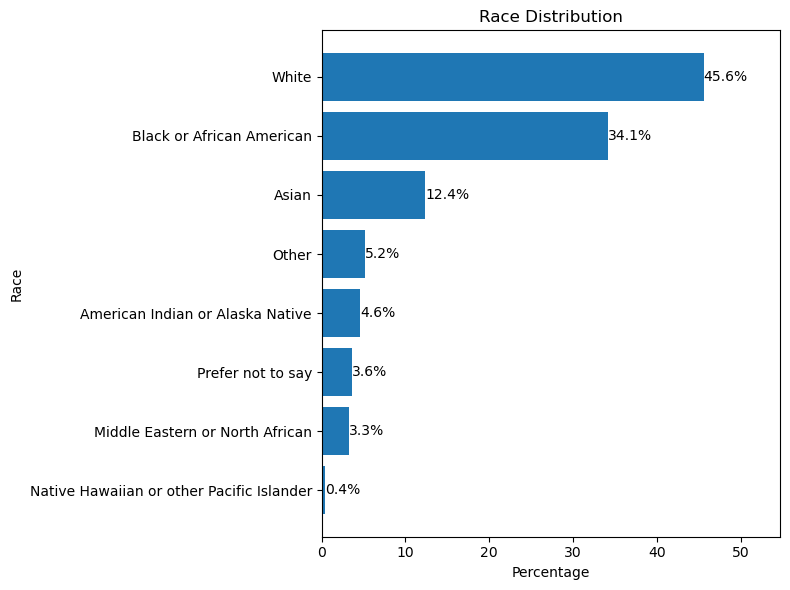

In [2]:
df = pd.read_csv("MBTA_2023_System-Wide_Passenger_Survey_Data.csv")
# Read the System-Wide Passenger Survey Data

Bus_Survey_Data = df[df['service_mode'] == 'Bus']
# Get only bus data from survey

race_data = Bus_Survey_Data[(Bus_Survey_Data['measure'] == 'Race')]
race_percentage = race_data.groupby('category')['weighted_percent'].mean().reset_index()
race_percentage = race_percentage.sort_values('weighted_percent', ascending=True)
print(race_percentage)

plt.figure(figsize=(8, 6))
plt.barh(race_percentage['category'], race_percentage['weighted_percent'] * 100)

plt.title('Race Distribution')
plt.xlabel('Percentage')
plt.ylabel('Race')


for i, v in enumerate(race_percentage['weighted_percent']):
    plt.text(v*100, i, f'{v*100:.1f}%', va='center')
max_percentage = race_percentage['weighted_percent'].max() * 100
plt.xlim(0, max_percentage * 1.2)
plt.tight_layout()

# Show the plot displaying race distribution 
plt.show()

In [9]:
def is_integer(s):
    try:
        int(s)
        return True
    except ValueError:
        return False

Top 10 Bus Routes (Minority Groups) by Weighted Percent:
     reporting_group  weighted_percent
909               23          0.903703
878               22          0.890091
669               15          0.870892
532               21          0.837399
1021              32          0.831628
29               104          0.817004
606               16          0.811798
349              111          0.782983
1697              66          0.683690
1402              39          0.671645


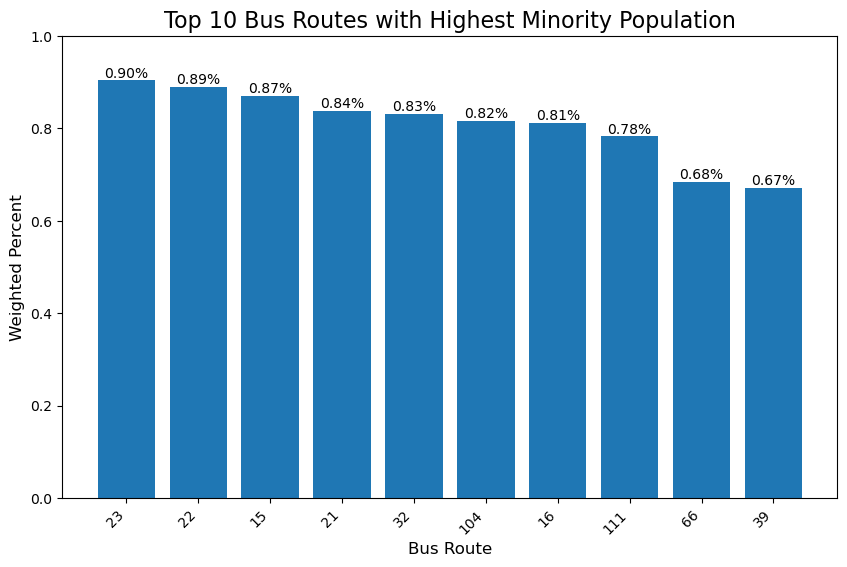

In [11]:
# Get data on top 10 bus routes with minority groups
minority_data = Bus_Survey_Data[(Bus_Survey_Data['measure'] == 'Title VI Minority') & (Bus_Survey_Data['category'] == 'Yes')]
minority_data = minority_data[minority_data['reporting_group'].apply(is_integer)]
top_10_reporting_groups = minority_data.nlargest(10, 'weighted_percent')


print("Top 10 Bus Routes (Minority Groups) by Weighted Percent:")
print(top_10_reporting_groups[['reporting_group', 'weighted_percent']])

plt.figure(figsize=(10, 6))
bars = plt.bar(top_10_reporting_groups['reporting_group'], top_10_reporting_groups['weighted_percent'])

plt.title('Top 10 Bus Routes with Highest Minority Population', fontsize=16)
plt.xlabel('Bus Route', fontsize=12)
plt.ylabel('Weighted Percent', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)  

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom')